In [2]:
%pip install --trusted-host https://mirror-pypi.runflare.com -i https://mirror-pypi.runflare.com/simple/ hazm

Looking in indexes: https://mirror-pypi.runflare.com/simple/
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/887.2 kB ? eta -:--:--
   ---------------------------------------- 0.0/887.2 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/887.2 kB ? eta -:--:--
   ----------------------- ---------------- 524.3/887.2 kB 1.1 MB/s eta 0:00:01
   ---------------------------------------- 887.2/887.2 kB 1.3 MB/s  0:00:00
   ---------------------------------------- 0.0/646.8 kB ? eta -:--:--
   ---------------------------------------- 0.0/646.8 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/646.8 kB ? eta -:--:--
   -------------------

In [78]:
%pip install --trusted-host https://mirror-pypi.runflare.com -i https://mirror-pypi.runflare.com/simple/ xgboost

^C
Note: you may need to restart the kernel to use updated packages.


Looking in indexes: https://mirror-pypi.runflare.com/simple/
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 1.4 MB/s eta 0:01:14
   ---------------------------------------- 0.8/101.7 MB 1.3 MB/s eta 0:01:19
   ---------------------------------------- 1.0/101.7 MB 1.3 MB/s eta 0:01:17
    --------------------------------------- 1.6/101.7 MB 1.3 MB/s eta 0:01:16
    --------------------------------------- 1.8/101.7 MB 1.3 MB/s eta 0:01:15
    --------------------------------------- 2.1/101.7 MB 1.3 MB/s eta 0:01:15
    --------------------------------------- 2.4/101.7 MB 1.3 MB/s eta 0:01:14
   - -------------------------------------- 2.6/101.7 MB 1.3 MB/s eta 0:01:14
   - -------------------------------------- 2.9/101.7 MB 1.3 MB/s eta 0:01:14
   - -------------------

In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
import xgboost as xgb

In [16]:
data = pd.read_csv('ecoli.data', header=None, sep='\s+')
data.head()

,0,1,2,3,4,5,6,7,8
0,AAT_ECOLI,0.49,0.29,0.48,0.5,0.56,0.24,0.35,cp
1,ACEA_ECOLI,0.07,0.40,0.48,0.5,0.54,0.35,0.44,cp
2,ACEK_ECOLI,0.56,0.40,0.48,0.5,0.49,0.37,0.46,cp
3,ACKA_ECOLI,0.59,0.49,0.48,0.5,0.52,0.45,0.36,cp
4,ADI_ECOLI,0.23,0.32,0.48,0.5,0.55,0.25,0.35,cp


In [10]:
X = data.iloc[:, 1:-1]
y = data.iloc[:, -1]
y.unique()

array(['cp', 'im', 'imS', 'imL', 'imU', 'om', 'omL', 'pp'], dtype=object)

In [20]:
encoder = LabelEncoder()
y = encoder.fit_transform(np.ravel(y))

In [48]:
sns.set_style('darkgrid')

<Axes: xlabel='8', ylabel='count'>

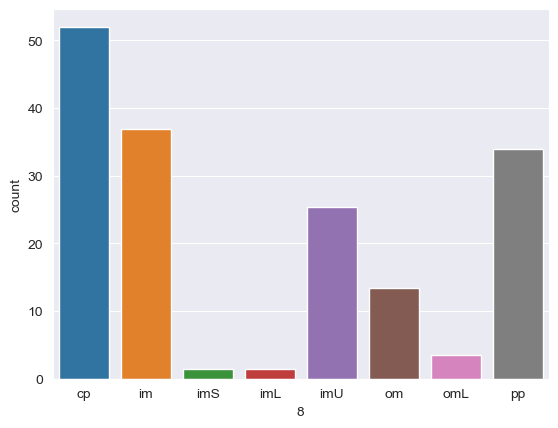

In [49]:

sns.countplot(data=data, x=data[8], hue=data[8])

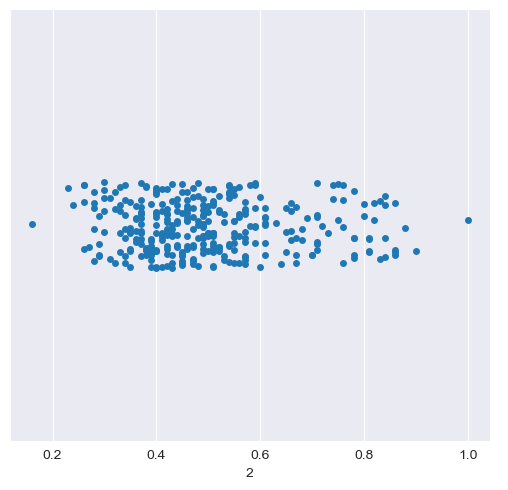

In [54]:
sns.catplot(data, x=2)

In [63]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=123)

In [72]:
knn = KNeighborsClassifier(n_neighbors=3)
scores = cross_val_score(knn, X, y, cv=5, verbose=10)
acc = scores.mean()
acc

[CV] START .....................................................................
[CV] END ................................ score: (test=0.868) total time=   0.0s
[CV] START .....................................................................
[CV] END ................................ score: (test=0.866) total time=   0.0s
[CV] START .....................................................................
[CV] END ................................ score: (test=0.776) total time=   0.0s
[CV] START .....................................................................
[CV] END ................................ score: (test=0.836) total time=   0.0s
[CV] START .....................................................................
[CV] END ................................ score: (test=0.776) total time=   0.0s


c:\Users\USER\anaconda3\envs\my_cloned_env\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   4 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.0s finished


np.float64(0.8242756804214224)

In [74]:
knn = KNeighborsClassifier()

param_grid = {
    'n_neighbors': np.arange(1, 51),
    'weights': ['uniform', 'distance']
}

grid_knn = GridSearchCV(knn, param_grid, cv=3)

grid_knn.fit(X, y)

print(grid_knn.best_params_)
print(grid_knn.best_score_)

c:\Users\USER\anaconda3\envs\my_cloned_env\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(


{'n_neighbors': np.int64(13), 'weights': 'distance'}
0.8541666666666666


In [77]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC())
])
param_grid = {
    'svc__C': [0.1, 1, 10, 100],
    'svc__kernel': ['linear', 'rbf', 'poly'],
    'svc__gamma': ['scale', 'auto'],
    'svc__degree': [2, 3, 4],
    'svc__class_weight': [None, 'balanced']
}

grid_svc = GridSearchCV(pipe, param_grid, scoring='accuracy', cv=5, verbose=5)
grid_svc.fit(X, y)

print(grid_svc.best_params_)
print(grid_svc.best_score_)

Fitting 5 folds for each of 144 candidates, totalling 720 fits
[CV 1/5] END svc__C=0.1, svc__class_weight=None, svc__degree=2, svc__gamma=scale, svc__kernel=linear;, score=0.912 total time=   0.0s
[CV 2/5] END svc__C=0.1, svc__class_weight=None, svc__degree=2, svc__gamma=scale, svc__kernel=linear;, score=0.881 total time=   0.0s
[CV 3/5] END svc__C=0.1, svc__class_weight=None, svc__degree=2, svc__gamma=scale, svc__kernel=linear;, score=0.791 total time=   0.0s
[CV 4/5] END svc__C=0.1, svc__class_weight=None, svc__degree=2, svc__gamma=scale, svc__kernel=linear;, score=0.881 total time=   0.0s
[CV 5/5] END svc__C=0.1, svc__class_weight=None, svc__degree=2, svc__gamma=scale, svc__kernel=linear;, score=0.821 total time=   0.0s
[CV 1/5] END svc__C=0.1, svc__class_weight=None, svc__degree=2, svc__gamma=scale, svc__kernel=rbf;, score=0.809 total time=   0.0s
[CV 2/5] END svc__C=0.1, svc__class_weight=None, svc__degree=2, svc__gamma=scale, svc__kernel=rbf;, score=0.791 total time=   0.0s
[CV 3

c:\Users\USER\anaconda3\envs\my_cloned_env\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


[CV 3/5] END svc__C=0.1, svc__class_weight=None, svc__degree=3, svc__gamma=scale, svc__kernel=linear;, score=0.791 total time=   0.0s
[CV 4/5] END svc__C=0.1, svc__class_weight=None, svc__degree=3, svc__gamma=scale, svc__kernel=linear;, score=0.881 total time=   0.0s
[CV 5/5] END svc__C=0.1, svc__class_weight=None, svc__degree=3, svc__gamma=scale, svc__kernel=linear;, score=0.821 total time=   0.0s
[CV 1/5] END svc__C=0.1, svc__class_weight=None, svc__degree=3, svc__gamma=scale, svc__kernel=rbf;, score=0.809 total time=   0.0s
[CV 2/5] END svc__C=0.1, svc__class_weight=None, svc__degree=3, svc__gamma=scale, svc__kernel=rbf;, score=0.791 total time=   0.0s
[CV 3/5] END svc__C=0.1, svc__class_weight=None, svc__degree=3, svc__gamma=scale, svc__kernel=rbf;, score=0.791 total time=   0.0s
[CV 4/5] END svc__C=0.1, svc__class_weight=None, svc__degree=3, svc__gamma=scale, svc__kernel=rbf;, score=0.776 total time=   0.0s
[CV 5/5] END svc__C=0.1, svc__class_weight=None, svc__degree=3, svc__gamma

In [89]:
classes, counts = np.unique(y, return_counts=True)
print(classes, counts)

[0 1 2 3 4 5 6 7] [143  77   2   2  35  20   5  52]


In [88]:
model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    tree_method="hist",
    device="cuda"
)

param_grid = {
    'n_estimators': [200, 400],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=2,
    verbose=10,
    n_jobs=-1
)

grid.fit(X, y)

print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_)

Fitting 2 folds for each of 32 candidates, totalling 64 fits


c:\Users\USER\anaconda3\envs\my_cloned_env\Lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Best Score: nan


In [65]:
pip = Pipeline([
    ('scaler', StandardScaler()),
    ('cls', KNeighborsClassifier())
])
pip.fit(X_train, y_train)

,steps,"[('scaler', ...), ('cls', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30


In [66]:
pip.predict(X_test)

array([0, 1, 6, 7, 1, 0, 7, 0, 7, 0, 0, 4, 4, 1, 0, 6, 0, 1, 0, 1, 1, 1,
       0, 1, 1, 7, 1, 0, 1, 0, 0, 0, 6, 0, 1, 0, 4, 7, 0, 1, 0, 1, 7, 0,
       7, 1, 1, 7, 1, 0, 1, 7, 0, 0, 1, 1, 4, 0, 4, 1, 0, 0, 1, 1, 0, 0,
       4, 7, 7, 0, 7, 1, 4, 0, 1, 0, 0, 0, 1, 7, 0, 1, 1, 0])

In [67]:
pip.score(X_test, y_test)

0.8690476190476191

In [3]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True